In [214]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [215]:
#load dadatset
df=pd.read_csv("Bengaluru_House_Data.csv")

Exploratory Data Analysis

In [216]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [217]:
#drop unwanted columns
cols=["area_type","availability","society","balcony"]
df=df.drop(cols,axis=1)
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [218]:
#Drop duplicates
df.drop_duplicates(inplace=True)

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12438 entries, 0 to 13318
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    12437 non-null  object 
 1   size        12422 non-null  object 
 2   total_sqft  12438 non-null  object 
 3   bath        12366 non-null  float64
 4   price       12438 non-null  float64
dtypes: float64(2), object(3)
memory usage: 583.0+ KB


In [220]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          72
price          0
dtype: int64

In [221]:
#Cleaning location column

#i)Remove leading and trailing spaces
df["location"]=df["location"].str.strip()

#ii)Handling nan values in location with top 2nd location --> Sarjapur  Road 
df["location"]=df["location"].fillna("Sarjapur  Road")

#iii)Grouping th elocations with less than 10 houses into Others category
loc=df["location"].value_counts()
loc_less_than_10=loc[loc<=10]

df["location"]=df["location"].apply(lambda x: "others" if x in loc_less_than_10 else x)

In [222]:
df["location"].value_counts()

location
others                  2927
Whitefield               508
Sarjapur  Road           365
Electronic City          275
Thanisandra              226
                        ... 
Tindlu                    11
Banashankari Stage V      11
Doddakallasandra          11
Thyagaraja Nagar          11
HAL 2nd Stage             11
Name: count, Length: 232, dtype: int64

In [223]:
#Cleaning size column

#i)handling nan values in size column
df["size"]=df["size"].fillna("2 BHK")

#ii)extract only the bhk number and remove unwanted characters
df["size"]=df["size"].apply(lambda x: int(x.split()[0]))
df["size"].unique()

#iii)Renaming size column to BHK
df.rename(columns={"size":"bhk"},inplace=True)

In [224]:
#Cleaning total_sqft column

def clean_total_sqft(sqft):
    try:
        l=sqft.split("-")
        if len(l)==2:
            return (float(l[0])+float(l[1]))/2
        else:
            return float(l[0])
    except:
        return None
    
df["total_sqft"]=df["total_sqft"].apply(clean_total_sqft)

#Handling nan values in total_sqft
df["total_sqft"]=df["total_sqft"].fillna(round(df["total_sqft"]).mean())

In [225]:
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9., nan,  8.,  7., 11., 10., 14.,
       27., 12., 16., 40., 15., 13., 18.])

In [226]:
#Handling nan values in bath
med=df["bath"].median()
df["bath"]=df["bath"].fillna(med)
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

In [227]:
#create a new column price_per_sqft
#formula: price_per_sqft=price/total_sqft

df["price_per_sqft"]=(df["price"]*100000)/df["total_sqft"]


In [228]:
df

,location,bhk,total_sqft,bath,price,price_per_sqft
0,Electronic City Phase II,2,1056.0,2.0,39.07,3699.810606
1,Chikka Tirupathi,4,2600.0,5.0,120.00,4615.384615
2,Uttarahalli,3,1440.0,2.0,62.00,4305.555556
3,Lingadheeranahalli,3,1521.0,3.0,95.00,6245.890861
4,Kothanur,2,1200.0,2.0,51.00,4250.000000
...,...,...,...,...,...,...
13314,Green Glen Layout,3,1715.0,3.0,112.00,6530.612245
13315,Whitefield,5,3453.0,4.0,231.00,6689.834926
13316,others,4,3600.0,5.0,400.00,11111.111111
13317,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,5258.545136


In [229]:
#Handling outliers in total_sqft
#Observation: In total_sqft column we have houses less than 300 sqft those are outliers
#In real-time, houses start with minimum of 300 sqft

#formula: total_sqft/bhk >= 300  --> it keeps all the realistic total sqft
#total_sqft >= 300
df=df[df["total_sqft"]/df["bhk"] >= 300]

All unrealistic rows with total_sqft <=300 got removed

<Axes: xlabel='bhk'>

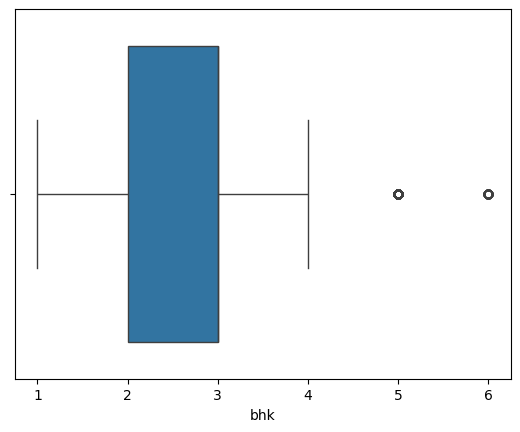

In [230]:
#Handling outliers in bhk column
df["bhk"].unique()
df=df[df["bhk"]<=6]
sns.boxplot(x="bhk",data=df)

In [231]:
#Handling outliers in bath column
df[df["bath"]>df["bhk"]+2][["bhk","bath"]]

#Observation: Here, no. of bath count is suspiciously high compared to bhk number these are outliers
df=df[df["bath"]<df["bhk"]+2]  #-->removes the unrealistic values where the no of bath count is suspiciously high compared to bhk number


<Axes: xlabel='price_per_sqft'>

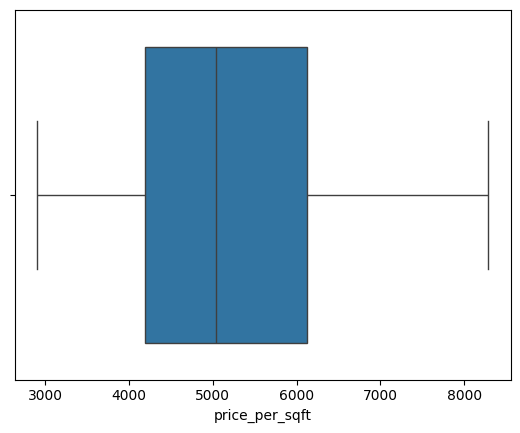

In [232]:
#Handling outliers in price_per_sqft
#IQR Method
q1=df["price_per_sqft"].quantile(0.25)
q3=df["price_per_sqft"].quantile(0.75)
IQR=q3-q1
lower=q1-0.5*IQR
upper=q3+0.5*IQR
df=df[(df["price_per_sqft"]>=lower) & (df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)

In [233]:
#remove price_per_sqft
df=df.drop("price_per_sqft",axis=1)

In [234]:
#reset index
df.drop("index", axis=1, inplace=True)

KeyError: "['index'] not found in axis"

In [ ]:
df

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
9356,Rachenahalli,2,1050.0,2.0,52.71
9357,Bellandur,2,1262.0,2.0,47.00
9358,Green Glen Layout,3,1715.0,3.0,112.00
9359,Whitefield,5,3453.0,4.0,231.00


Text(0, 0.5, 'Price')

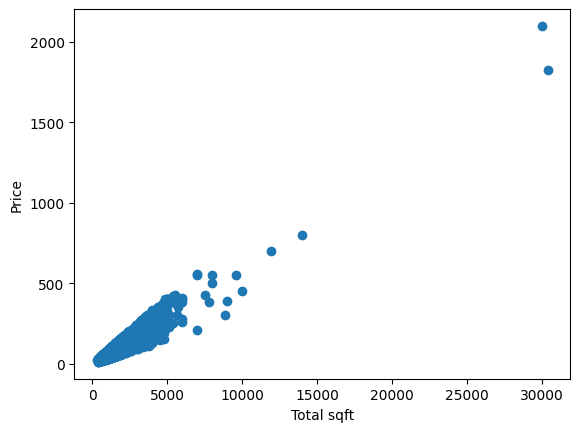

In [ ]:
plt.scatter(df["total_sqft"],df["price"])
plt.xlabel("Total sqft")
plt.ylabel("Price")

<Axes: >

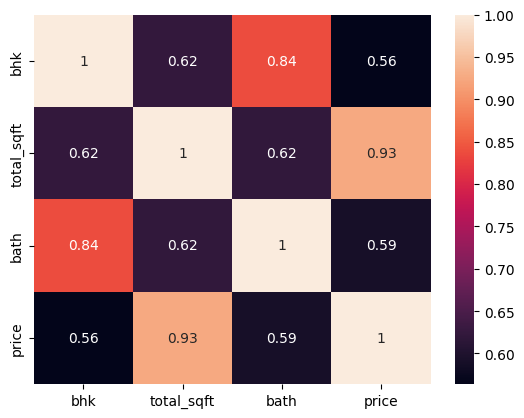

In [ ]:
corr_data=df.iloc[:,1:].corr()
sns.heatmap(corr_data,annot=True)

In [ ]:
#Avg Price by location
data=df.groupby("location")["price"].mean().sort_values()
data

location
Kereguddadahalli         34.678571
Dommasandra              37.837500
Bisuvanahalli            40.805000
Anekal                   41.216000
Giri Nagar               42.000000
                           ...    
Hebbal Kempapura        154.363636
Doddaballapur           157.375000
Sector 7 HSR Layout     195.500000
2nd Stage Nagarbhavi    205.000000
Iblur Village           227.250000
Name: price, Length: 231, dtype: float64

Model Training & Evaluation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_absolute_error


In [ ]:
#Encoding location column
encoder=LabelEncoder()
df["encoded_loc"]=encoder.fit_transform(df["location"])

In [ ]:
df

,location,bhk,total_sqft,bath,price,encoded_loc
0,Electronic City Phase II,2,1056.0,2.0,39.07,75
1,Chikka Tirupathi,4,2600.0,5.0,120.00,57
2,Uttarahalli,3,1440.0,2.0,62.00,216
3,Lingadheeranahalli,3,1521.0,3.0,95.00,154
4,Kothanur,2,1200.0,2.0,51.00,146
...,...,...,...,...,...,...
9356,Rachenahalli,2,1050.0,2.0,52.71,183
9357,Bellandur,2,1262.0,2.0,47.00,40
9358,Green Glen Layout,3,1715.0,3.0,112.00,83
9359,Whitefield,5,3453.0,4.0,231.00,224


In [ ]:
#Divide data into input and output features
X=df.drop(["location","price"],axis=1)
y=df.price

In [ ]:
#split the data for training and testing 
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=42)

Linear Regression

In [ ]:
#Model Training
LR=LinearRegression()
LR.fit(Xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
ypred=LR.predict(Xtest)
ypred

array([82.02245112, 62.36589697, 78.92811651, ..., 67.2194717 ,
       63.22777854, 66.58749575], shape=(2809,))

In [ ]:
print("Training Eff: ",LR.score(Xtrain,ytrain))
print("Testing Eff: ",LR.score(Xtest,ytest))
print("R2 Score: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Training Eff:  0.8729434071593825
Testing Eff:  0.811914036986753
R2 Score:  0.811914036986753
MAE:  14.795892200656548


Decision Tree

In [ ]:
DT=DecisionTreeRegressor()
DT.fit(Xtrain,ytrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [ ]:
ypred=DT.predict(Xtest)
ypred

array([123.  ,  44.  ,  68.  , ...,  58.17,  50.  ,  95.  ], shape=(2809,))

In [ ]:
print("Training Eff: ",DT.score(Xtrain,ytrain))
print("Testing Eff: ",DT.score(Xtest,ytest))
print("R2 Score: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Training Eff:  0.991086473248075
Testing Eff:  0.7153907631422789
R2 Score:  0.7153907631422789
MAE:  15.693633404903458


Decision Tree is Overfitting cause the data is linear
Here Linear Regression is the best performing model

In [ ]:
#Model serialization  --> saving the trained model
#using pickle
#req: it skips the continuous training process

import pickle
with open("Linear_model.pkl","wb") as file:
    pickle.dump(LR,file)

In [ ]:
# #using joblib
# import joblib
# file="model.pkl"
# joblib.dump(LR,file)

['model.pkl']

In [237]:
#encoder serilaization
with open("label_encoder.pkl","wb") as file:
    pickle.dump(encoder,file)

In [238]:
#save the cleaned dataset
df.to_csv("cleaned_data.csv")

In [240]:
df

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
13310,Rachenahalli,2,1050.0,2.0,52.71
13312,Bellandur,2,1262.0,2.0,47.00
13314,Green Glen Layout,3,1715.0,3.0,112.00
13315,Whitefield,5,3453.0,4.0,231.00
